In [1]:
# ============================================================
# CELDA 1 — Imports y carga del dataset limpio
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

# Estilo gráficos
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Rutas
BASE      = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED = os.path.join(BASE, 'data', 'processed')
REPORTS   = os.path.join(BASE, 'reports')
os.makedirs(REPORTS, exist_ok=True)

# Carga
df = pd.read_csv(os.path.join(PROCESSED, 'listings_clean.csv'), low_memory=False)

print(f"Dataset cargado: {df.shape[0]:,} filas | {df.shape[1]} columnas")
print(f"\n--- Ciudades ---")
print(df.groupby(['ciudad', 'fecha_scrape']).size().reset_index(name='anuncios'))

Dataset cargado: 69,142 filas | 33 columnas

--- Ciudades ---
      ciudad fecha_scrape  anuncios
0  barcelona      jun2025     14897
1  barcelona      sep2025     15261
2     madrid      jun2025     20054
3     madrid      sep2025     18930


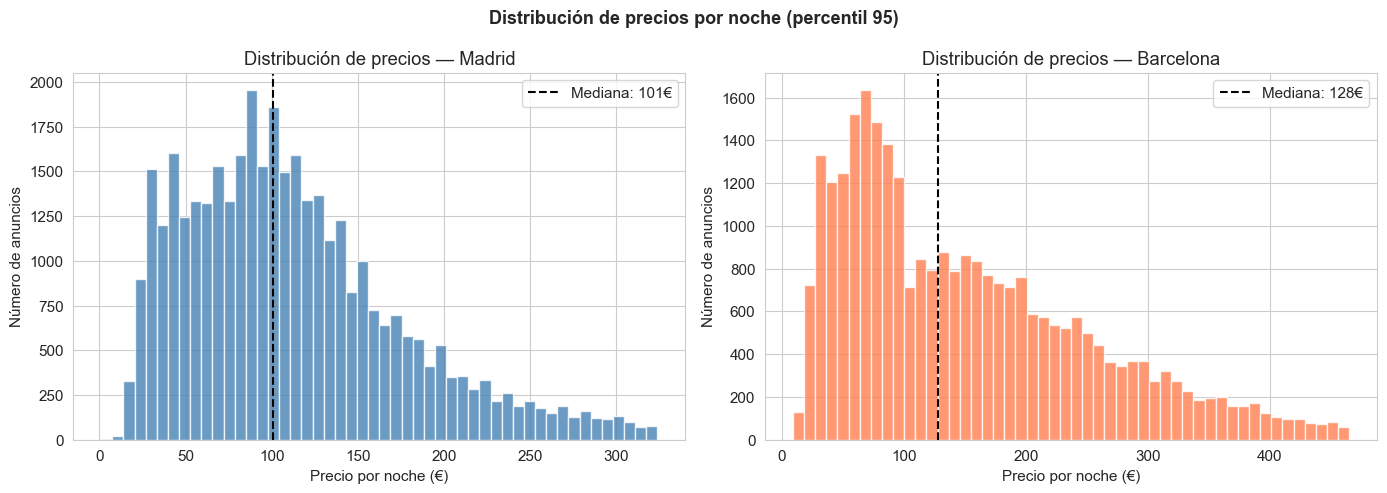


--- Estadísticas de precio por ciudad ---
             count   mean    std  min   25%    50%    75%     max
ciudad                                                           
barcelona 30158.00 192.10 258.82 9.00 71.00 136.00 233.00 5000.00
madrid    38984.00 136.45 171.46 1.00 67.00 105.00 156.00 5000.00


In [2]:
# ============================================================
# CELDA 2 — Distribución de precios por ciudad
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ciudad in zip(axes, ['madrid', 'barcelona']):
    datos = df[df['ciudad'] == ciudad]['price']
    # Filtramos percentil 95 para visualización
    datos = datos[datos <= datos.quantile(0.95)]
    
    ax.hist(datos, bins=50, color='steelblue' if ciudad == 'madrid' else 'coral', 
            edgecolor='white', alpha=0.8)
    ax.set_title(f'Distribución de precios — {ciudad.capitalize()}')
    ax.set_xlabel('Precio por noche (€)')
    ax.set_ylabel('Número de anuncios')
    ax.axvline(datos.median(), color='black', linestyle='--', linewidth=1.5, 
               label=f'Mediana: {datos.median():.0f}€')
    ax.legend()

plt.suptitle('Distribución de precios por noche (percentil 95)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'distribucion_precios.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Estadísticas de precio por ciudad ---")
print(df.groupby('ciudad')['price'].describe().round(2))

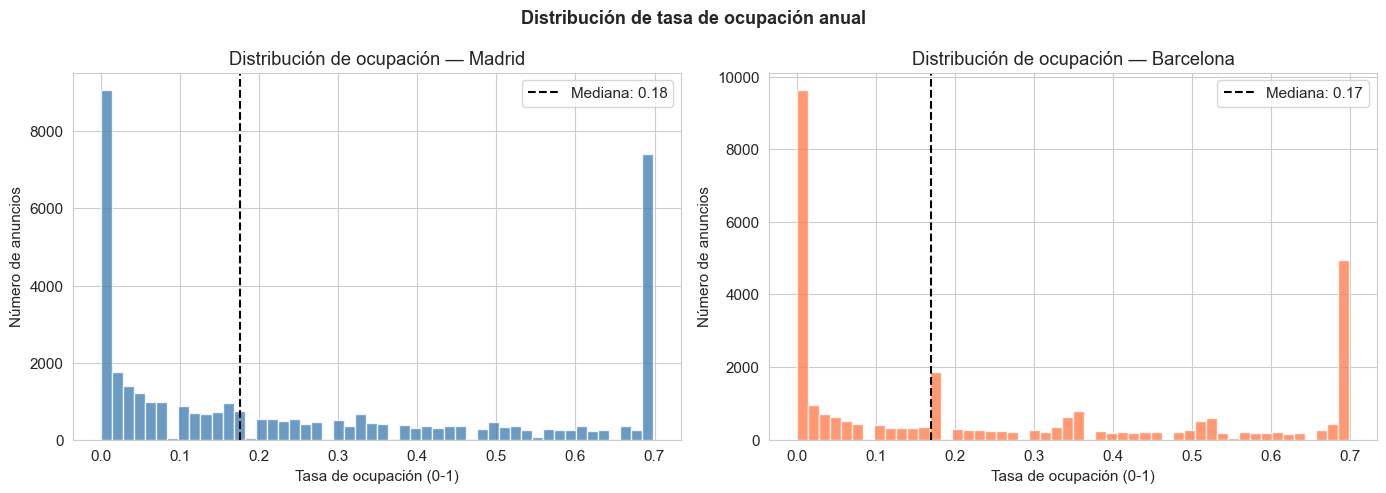


--- Estadísticas de ocupación por ciudad ---
             count  mean  std  min  25%  50%  75%  max
ciudad                                                
barcelona 30158.00  0.26 0.27 0.00 0.00 0.17 0.53 0.70
madrid    38984.00  0.28 0.27 0.00 0.02 0.17 0.54 0.70

--- Ocupación media por tipo de habitación ---
room_type  Entire home/apt  Hotel room  Private room  Shared room
ciudad                                                           
barcelona             0.29        0.24          0.20         0.21
madrid                0.30        0.04          0.22         0.19


In [3]:
# ============================================================
# CELDA 3 — Distribución de ocupación por ciudad
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ciudad in zip(axes, ['madrid', 'barcelona']):
    datos = df[df['ciudad'] == ciudad]['ocupacion']
    
    ax.hist(datos, bins=50, color='steelblue' if ciudad == 'madrid' else 'coral',
            edgecolor='white', alpha=0.8)
    ax.set_title(f'Distribución de ocupación — {ciudad.capitalize()}')
    ax.set_xlabel('Tasa de ocupación (0-1)')
    ax.set_ylabel('Número de anuncios')
    ax.axvline(datos.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mediana: {datos.median():.2f}')
    ax.legend()

plt.suptitle('Distribución de tasa de ocupación anual', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'distribucion_ocupacion.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Estadísticas de ocupación por ciudad ---")
print(df.groupby('ciudad')['ocupacion'].describe().round(3))

print("\n--- Ocupación media por tipo de habitación ---")
print(df.groupby(['ciudad', 'room_type'])['ocupacion'].mean().round(3).unstack())

In [5]:
# ============================================================
# CELDA 4 — Top 15 barrios por precio medio y ocupación
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, ciudad in enumerate(['madrid', 'barcelona']):
    datos = df[df['ciudad'] == ciudad]
    
    # Top 15 barrios por precio medio
    top_precio = (datos.groupby('neighbourhood_cleansed')['price']
                  .median()
                  .sort_values(ascending=False)
                  .head(15))
    
    ax = axes[0][idx]
    top_precio.plot(kind='barh', ax=ax, 
                   color='steelblue' if ciudad == 'madrid' else 'coral')
    ax.set_title(f'{ciud

_IncompleteInputError: incomplete input (3717220916.py, line 19)

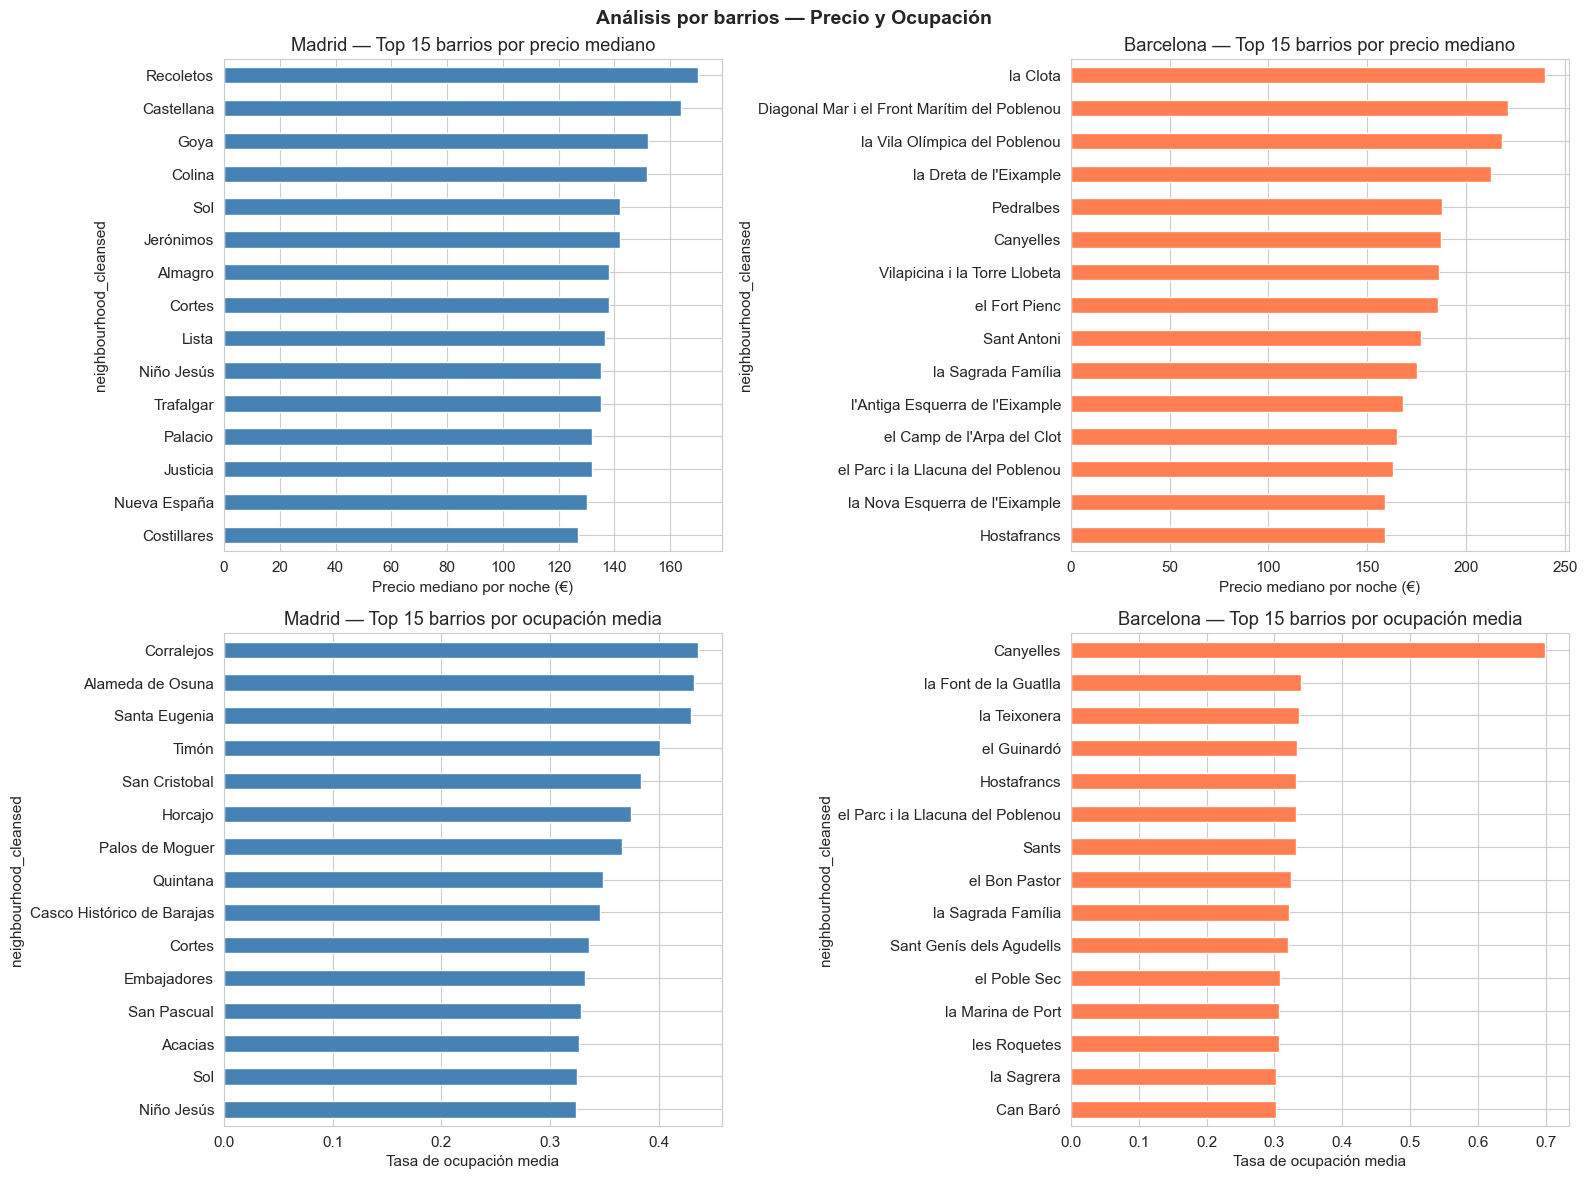

In [6]:
# ============================================================
# CELDA 4 — Top 15 barrios por precio medio y ocupación
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, ciudad in enumerate(['madrid', 'barcelona']):
    datos = df[df['ciudad'] == ciudad]

    # Top 15 barrios por precio medio
    top_precio = (datos.groupby('neighbourhood_cleansed')['price']
                  .median()
                  .sort_values(ascending=False)
                  .head(15))

    ax = axes[0][idx]
    top_precio.plot(kind='barh', ax=ax,
                    color='steelblue' if ciudad == 'madrid' else 'coral')
    ax.set_title(f'{ciudad.capitalize()} — Top 15 barrios por precio mediano')
    ax.set_xlabel('Precio mediano por noche (€)')
    ax.invert_yaxis()

    # Top 15 barrios por ocupación media
    top_ocup = (datos.groupby('neighbourhood_cleansed')['ocupacion']
                .mean()
                .sort_values(ascending=False)
                .head(15))

    ax = axes[1][idx]
    top_ocup.plot(kind='barh', ax=ax,
                  color='steelblue' if ciudad == 'madrid' else 'coral')
    ax.set_title(f'{ciudad.capitalize()} — Top 15 barrios por ocupación media')
    ax.set_xlabel('Tasa de ocupación media')
    ax.invert_yaxis()

plt.suptitle('Análisis por barrios — Precio y Ocupación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'top_barrios.png'), dpi=150, bbox_inches='tight')
plt.show()

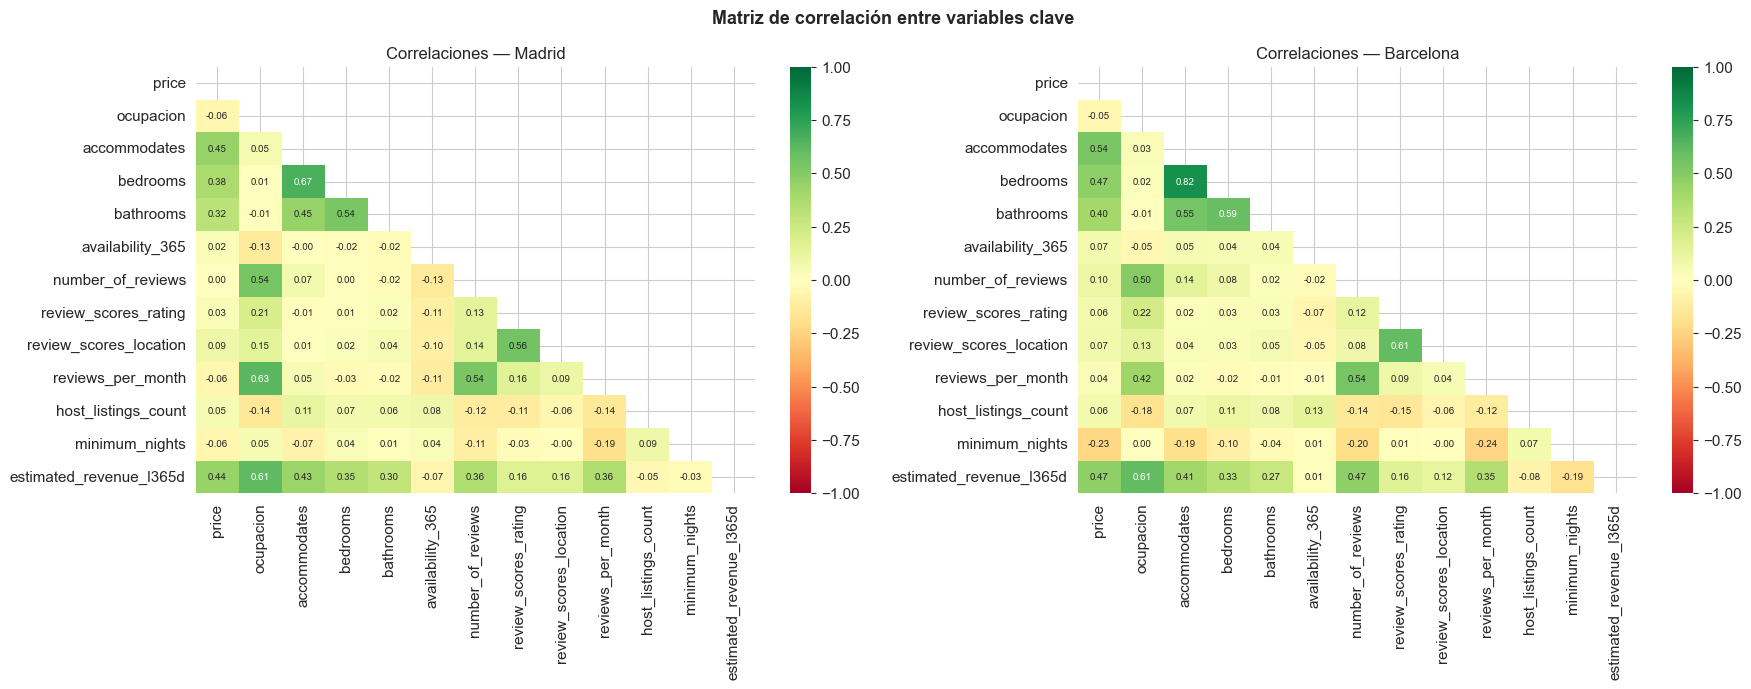

--- Correlaciones con PRECIO (Madrid) ---
price                      1.00
accommodates               0.45
estimated_revenue_l365d    0.44
bedrooms                   0.38
bathrooms                  0.32
review_scores_location     0.09
host_listings_count        0.05
review_scores_rating       0.03
availability_365           0.02
number_of_reviews          0.00
minimum_nights            -0.06
reviews_per_month         -0.06
ocupacion                 -0.06
Name: price, dtype: float64

--- Correlaciones con OCUPACIÓN (Madrid) ---
ocupacion                  1.00
reviews_per_month          0.62
estimated_revenue_l365d    0.61
number_of_reviews          0.54
review_scores_rating       0.21
review_scores_location     0.15
accommodates               0.06
minimum_nights             0.05
bedrooms                   0.01
bathrooms                 -0.01
price                     -0.06
availability_365          -0.13
host_listings_count       -0.14
Name: ocupacion, dtype: float64


In [7]:
# ============================================================
# CELDA 5 — Matriz de correlación
# ============================================================

vars_correlacion = [
    'price', 'ocupacion', 'accommodates', 'bedrooms',
    'bathrooms', 'availability_365', 'number_of_reviews',
    'review_scores_rating', 'review_scores_location',
    'reviews_per_month', 'host_listings_count',
    'minimum_nights', 'estimated_revenue_l365d'
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, ciudad in zip(axes, ['madrid', 'barcelona']):
    datos = df[df['ciudad'] == ciudad][vars_correlacion].dropna()
    corr  = datos.corr()
    
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='RdYlGn', center=0, vmin=-1, vmax=1,
                ax=ax, annot_kws={'size': 7})
    ax.set_title(f'Correlaciones — {ciudad.capitalize()}', fontsize=12)

plt.suptitle('Matriz de correlación entre variables clave', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'correlaciones.png'), dpi=150, bbox_inches='tight')
plt.show()

# Correlaciones más relevantes con precio y ocupación
print("--- Correlaciones con PRECIO (Madrid) ---")
datos_mad = df[df['ciudad']=='madrid'][vars_correlacion].dropna()
print(datos_mad.corr()['price'].sort_values(ascending=False).round(3))

print("\n--- Correlaciones con OCUPACIÓN (Madrid) ---")
print(datos_mad.corr()['ocupacion'].sort_values(ascending=False).round(3))

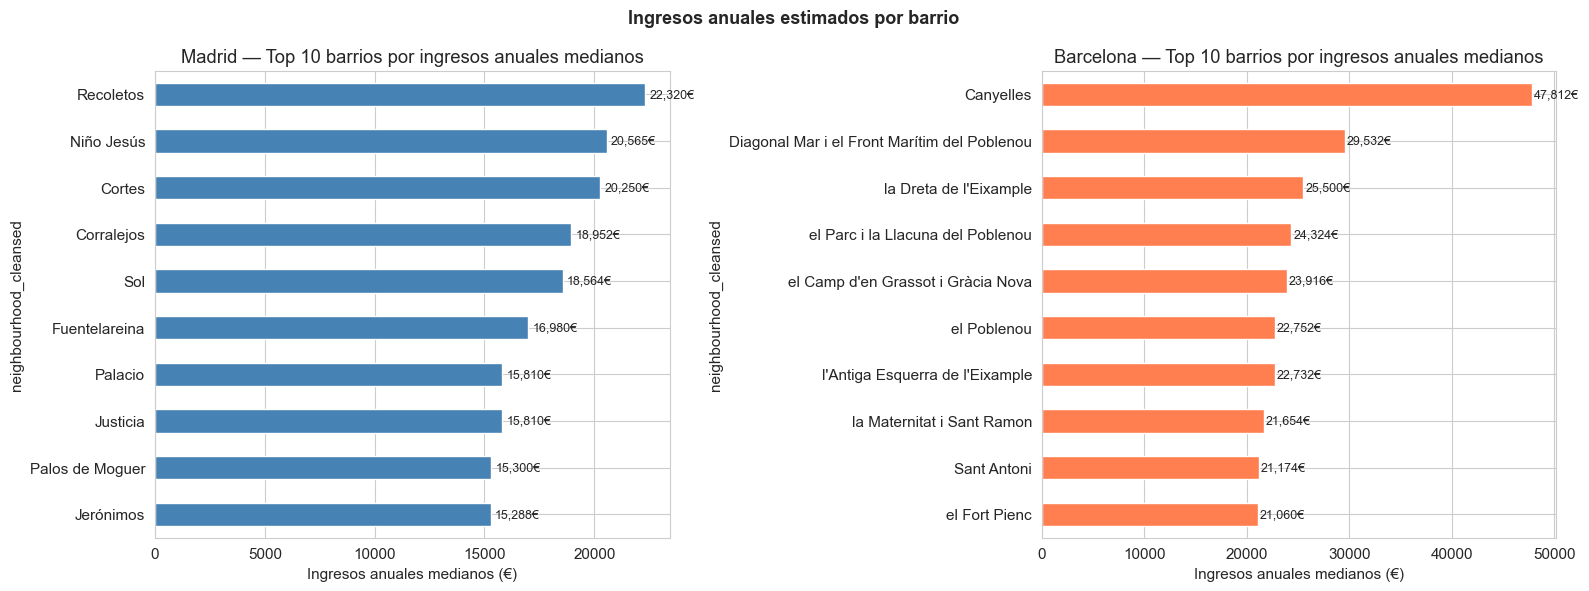


--- Resumen ejecutivo del análisis exploratorio ---
Total anuncios analizados:     69,142
Madrid — precio mediano:       105€/noche
Barcelona — precio mediano:    136€/noche
Madrid — ocupación mediana:    17.5%
Barcelona — ocupación mediana: 17.0%
Madrid — ingresos medianos:    6,144€/año
Barcelona — ingresos medianos: 6,816€/año


In [8]:
# ============================================================
# CELDA 6 — Ingresos anuales estimados por barrio (Top 10)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, ciudad in zip(axes, ['madrid', 'barcelona']):
    datos = df[(df['ciudad'] == ciudad) & (df['estimated_revenue_l365d'] > 0)]
    
    top_ingresos = (datos.groupby('neighbourhood_cleansed')['estimated_revenue_l365d']
                    .median()
                    .sort_values(ascending=False)
                    .head(10))
    
    top_ingresos.plot(kind='barh', ax=ax,
                      color='steelblue' if ciudad == 'madrid' else 'coral')
    ax.set_title(f'{ciudad.capitalize()} — Top 10 barrios por ingresos anuales medianos')
    ax.set_xlabel('Ingresos anuales medianos (€)')
    ax.invert_yaxis()
    
    # Añadimos etiquetas
    for i, v in enumerate(top_ingresos.values):
        ax.text(v + 200, i, f'{v:,.0f}€', va='center', fontsize=9)

plt.suptitle('Ingresos anuales estimados por barrio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'ingresos_por_barrio.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Resumen ejecutivo del análisis exploratorio ---")
print(f"Total anuncios analizados:     {len(df):,}")
print(f"Madrid — precio mediano:       {df[df['ciudad']=='madrid']['price'].median():.0f}€/noche")
print(f"Barcelona — precio mediano:    {df[df['ciudad']=='barcelona']['price'].median():.0f}€/noche")
print(f"Madrid — ocupación mediana:    {df[df['ciudad']=='madrid']['ocupacion'].median():.1%}")
print(f"Barcelona — ocupación mediana: {df[df['ciudad']=='barcelona']['ocupacion'].median():.1%}")
print(f"Madrid — ingresos medianos:    {df[df['ciudad']=='madrid']['estimated_revenue_l365d'].median():,.0f}€/año")
print(f"Barcelona — ingresos medianos: {df[df['ciudad']=='barcelona']['estimated_revenue_l365d'].median():,.0f}€/año")